# Day 21 — Best Candidate Review

## Objective

This review compares the YOLOv8n baseline with the tuned candidate models and analyses the project-specific Raw vs WB+CLAHE study.

### Main Activities

- Compare baseline and tuned results.
- Review the project-specific enhancement study.
- Identify representative successes and failures.
- Discuss remaining weaknesses and unusual errors.
- Select the candidate configurations for the final project direction.
- Prepare the results for mentor review and approval.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("Day 21 - Best Candidate Review")
print("Environment ready.")

Day 21 - Best Candidate Review
Environment ready.


## Baseline vs Tuned Results

Day 19 hyperparameter tuning was performed on the shortlisted Aquatic Plant and Well candidates.

The experiments varied learning rate and batch size while keeping YOLOv8n,640×640 input size,AdamW optimizer,and 30 training epochs.

Validation mAP@0.5:0.95 was used as the primary selection metric.

In [ ]:
tuning_data=[
["H01","Aquatic Plant",0.001,16,94.5,95.4,98.2,71.3],
["H02","Aquatic Plant",0.0005,16,94.5,94.9,98.2,71.4],
["H03","Aquatic Plant",0.0005,32,95.4,96.1,98.5,71.5],
["H04","Well",0.001,16,35.7,40.1,36.8,16.8],
["H05","Well",0.0005,16,43.6,33.5,37.2,16.4],
["H06","Well",0.001,32,34.4,34.5,35.3,16.1]
]
tuning_df=pd.DataFrame(
    tuning_data,
    columns=[
        "Experiment","Dataset","Learning_Rate","Batch_Size",
        "Precision","Recall","mAP50","mAP50_95"
    ]
)
display(tuning_df)

,Experiment,Dataset,Learning_Rate,Batch_Size,Precision,Recall,mAP50,mAP50_95
0,H01,Aquatic Plant,0.0010,16,94.5,95.4,98.2,71.3
1,H02,Aquatic Plant,0.0005,16,94.5,94.9,98.2,71.4
2,H03,Aquatic Plant,0.0005,32,95.4,96.1,98.5,71.5
3,H04,Well,0.0010,16,35.7,40.1,36.8,16.8
4,H05,Well,0.0005,16,43.6,33.5,37.2,16.4
5,H06,Well,0.0010,32,34.4,34.5,35.3,16.1


## Tuned Candidate Selection

- **Aquatic Plant:** H03 achieved the highest validation mAP@0.5:0.95 of **71.5%**.
- **Well:** H04 achieved the highest validation mAP@0.5:0.95 of **16.8%**.
- H03 and H04 are therefore carried forward as the selected tuned candidates.
- H01,H02,H05,and H06 remain part of the documented tuning study.
- Selection is based on validation evidence; the test sets are not used for tuning.

## Baseline vs Selected Tuned Candidates

The selected tuned configurations are compared with the original YOLOv8n baseline.

- Aquatic Plant: H03 is the selected tuned candidate.
- Well: H04 is the selected tuned candidate.
- Validation mAP@0.5:0.95 is used as the primary comparison metric.

In [ ]:
comparison_data=[
["Aquatic Plant","Original Baseline",94.64,93.52,98.05,70.79],
["Aquatic Plant","H03 Tuned",95.40,96.10,98.50,71.50],
["Well","Original Baseline",35.60,36.80,36.50,16.40],
["Well","H04 Tuned",35.70,40.10,36.80,16.80]
]
comparison_df=pd.DataFrame(
    comparison_data,
    columns=["Dataset","Model","Precision","Recall","mAP50","mAP50_95"]
)
display(comparison_df)

,Dataset,Model,Precision,Recall,mAP50,mAP50_95
0,Aquatic Plant,Original Baseline,94.64,93.52,98.05,70.79
1,Aquatic Plant,H03 Tuned,95.40,96.10,98.50,71.50
2,Well,Original Baseline,35.60,36.80,36.50,16.40
3,Well,H04 Tuned,35.70,40.10,36.80,16.80


## Improvement from Baseline to Selected Candidate

The selected tuned candidates are compared with their corresponding original YOLOv8n baselines.

The change is calculated in percentage points (pp).

In [ ]:
improvement_data=[
["Aquatic Plant","H03",95.40-94.64,96.10-93.52,98.50-98.05,71.50-70.79],
["Well","H04",35.70-35.60,40.10-36.80,36.80-36.50,16.80-16.40]
]
improvement_df=pd.DataFrame(
    improvement_data,
    columns=["Dataset","Selected Model","Precision Change","Recall Change","mAP50 Change","mAP50_95 Change"]
)
display(improvement_df)

,Dataset,Selected Model,Precision Change,Recall Change,mAP50 Change,mAP50_95 Change
0,Aquatic Plant,H03,0.76,2.58,0.45,0.71
1,Well,H04,0.10,3.30,0.30,0.40


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


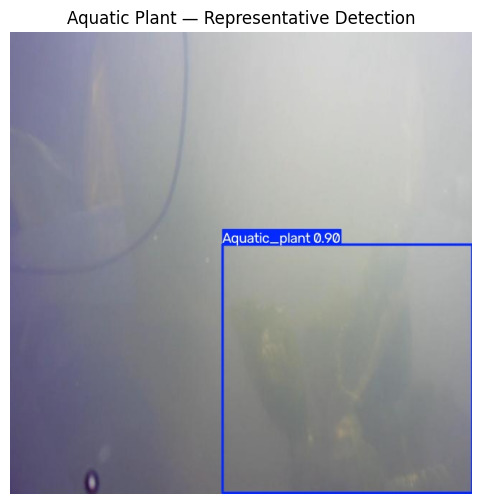

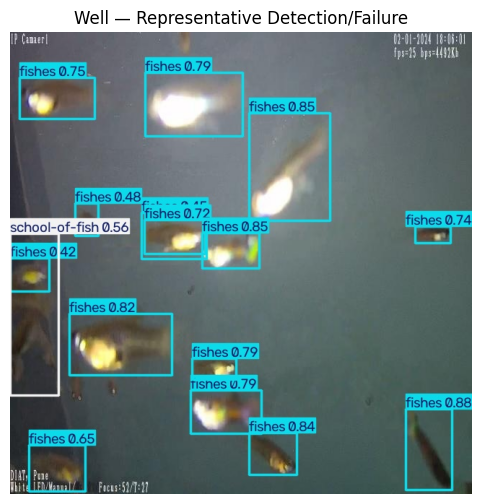

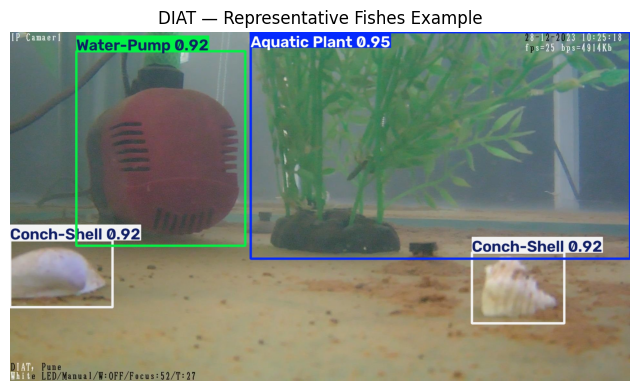

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
examples=[
    (
        "Aquatic Plant — Representative Detection",
        "/content/drive/MyDrive/Day16_YOLO_Baseline/Aquatic_Plant/predictions/validation_predictions"
    ),
    (
        "Well — Representative Detection/Failure",
        "/content/drive/MyDrive/Day16_YOLO_Baseline/Well/predictions/visual_outputs/well_validation_predictions"
    ),
    (
        "DIAT — Representative Fishes Example",
        "/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions"
    )
]
for title,folder in examples:
    files=sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])
    if files:
        path=os.path.join(folder,files[0])
        img=Image.open(path)
        plt.figure(figsize=(8,6))
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")
        plt.show()

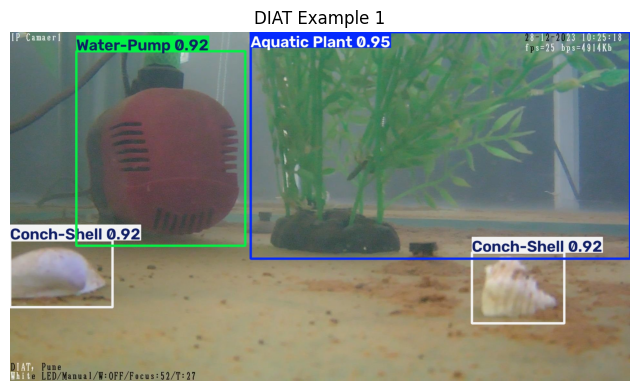

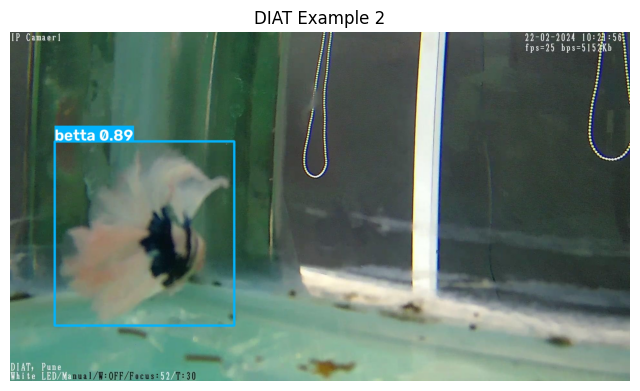

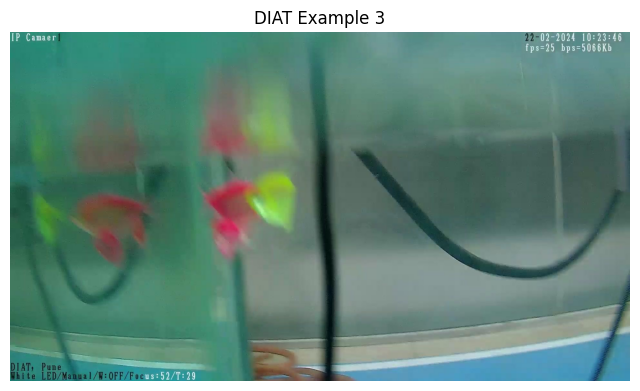

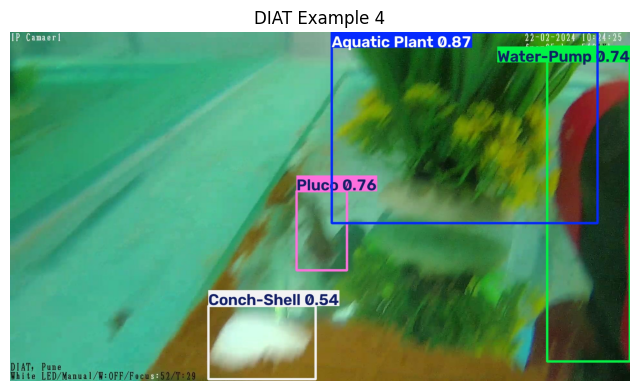

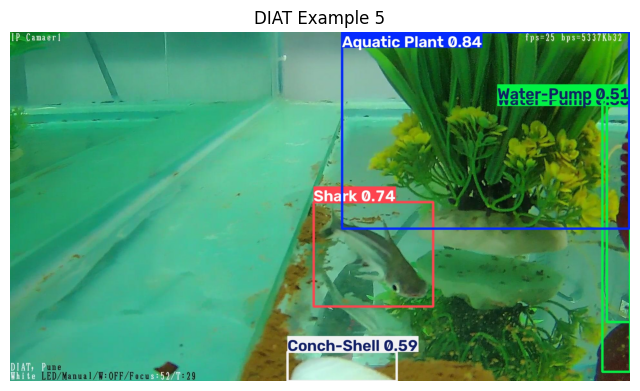

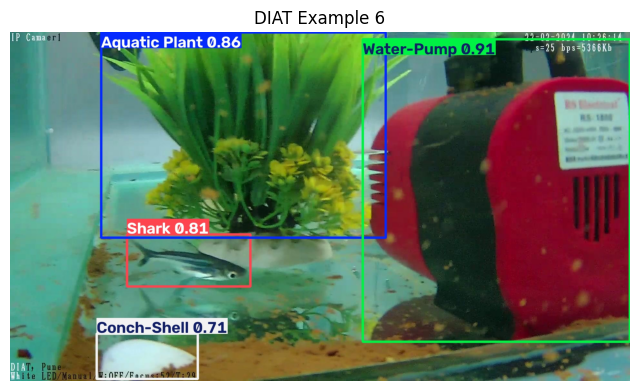

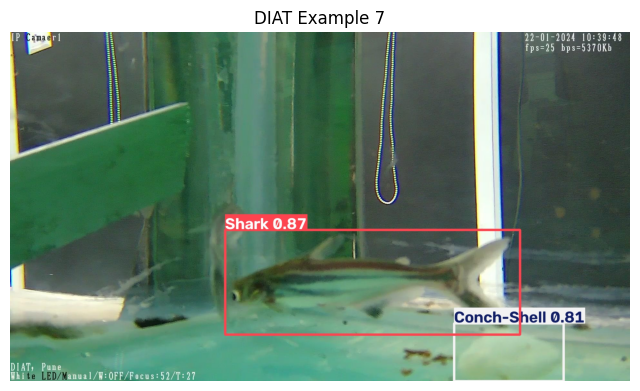

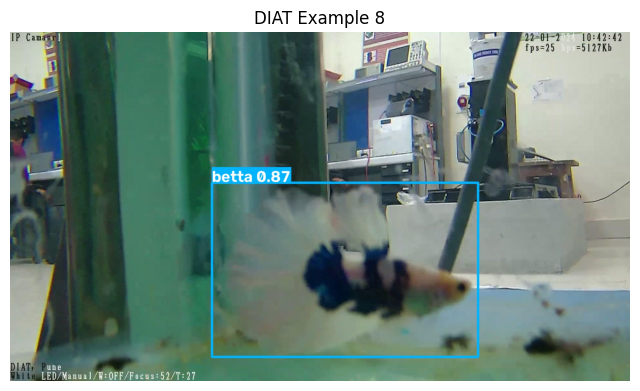

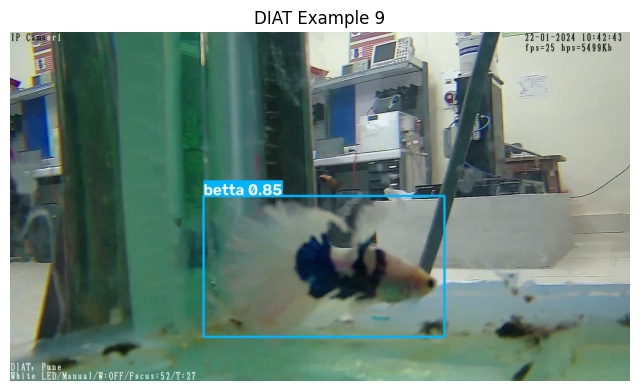

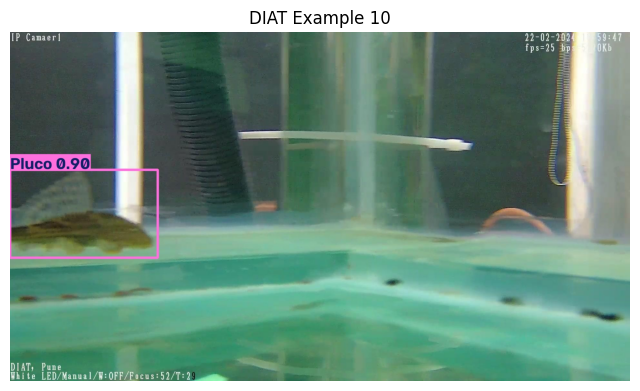

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

folder="/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/predictions/validation_predictions"

files=sorted([
    f for f in os.listdir(folder)
    if f.lower().endswith((".jpg",".jpeg",".png"))
])

for i,f in enumerate(files):
    img=Image.open(os.path.join(folder,f))
    plt.figure(figsize=(8,5))
    plt.imshow(img)
    plt.title(f"DIAT Example {i+1}")
    plt.axis("off")
    plt.show()

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
model_path="/content/drive/MyDrive/Day16_YOLO_Baseline/DIATAquarium/weights/best.pt"
model=YOLO(model_path)

print("Model loaded successfully.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Model loaded successfully.


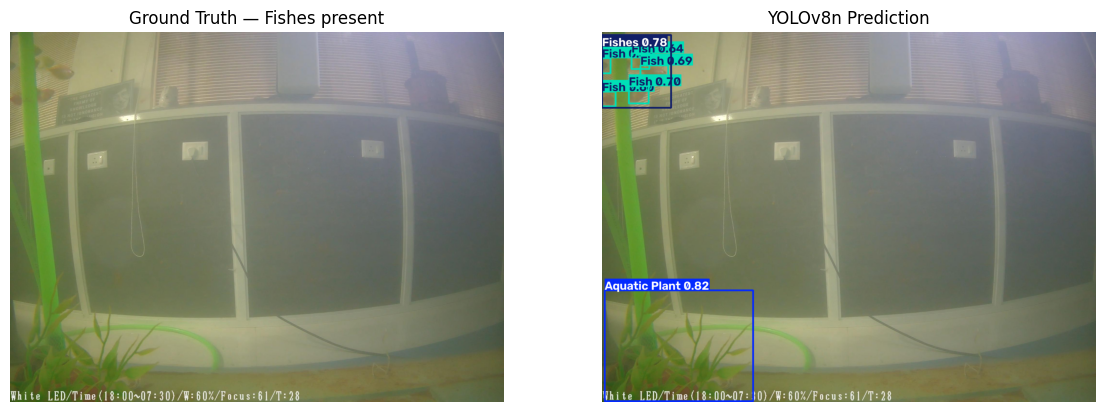

Image: av0_0_20231228_094444_mp4-106_jpg.rf.12f8943444344b67f425b1574a2cd69a.jpg
Ground-truth Fishes objects: 1


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
DIAT_BASE="/content/drive/MyDrive/Dataset_V1/DIATAquarium.v4i.yolov8"
VAL_IMAGES=os.path.join(DIAT_BASE,"valid/images")
VAL_LABELS=os.path.join(DIAT_BASE,"valid/labels")
FISHES_CLASS_ID=4
found=False
for file in sorted(os.listdir(VAL_IMAGES)):
    if not file.lower().endswith((".jpg",".jpeg",".png")):
        continue
    image_path=os.path.join(VAL_IMAGES,file)
    label_path=os.path.join(VAL_LABELS,os.path.splitext(file)[0]+".txt")
    if not os.path.exists(label_path):
        continue
    labels=[]
    with open(label_path,"r") as f:
        for line in f:
            parts=line.strip().split()
            if len(parts)==5:
                labels.append([int(parts[0])]+[float(x) for x in parts[1:]])
    if not any(x[0]==FISHES_CLASS_ID for x in labels):
        continue
    results=model.predict(image_path,conf=0.25,verbose=False)
    img=cv2.imread(image_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    annotated=results[0].plot()
    annotated=cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14,6))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Ground Truth — Fishes present")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(annotated)
    plt.title("YOLOv8n Prediction")
    plt.axis("off")
    plt.show()
    print("Image:",file)
    print("Ground-truth Fishes objects:",sum(x[0]==FISHES_CLASS_ID for x in labels))
    found=True
    break
if not found:
    print("No validation image containing the Fishes class was found.")

## Note on Day 20 and Day 21 Results

The WB+CLAHE results used in the Day 20 robustness/ablation study were obtained from the original untuned Day 17 models.

The H03 and H04 configurations reviewed in Day 21 are the hyperparameter-tuned models from Day 19.

Therefore,the Day 20 WB+CLAHE results and the Day 21 H03/H04 results represent different model checkpoints and should not be treated as the same experiment.

## Representative Prediction Examples

Representative prediction examples were reviewed to visually inspect model behaviour and complement the quantitative results.

- **Aquatic Plant — Original YOLOv8n:** representative successful detection of an aquatic plant with 0.90 confidence.
- **Well — Original YOLOv8n:** representative challenging scene containing multiple fish detections and a school-of-fish detection.
- **DIAT — Original YOLOv8n:** representative `Fish`/`Fishes` class-confusion example where a ground-truth `Fishes` object is present.

These examples are representative visual evidence and are not direct prediction outputs from the H03/H04 tuned checkpoints,because those model files were not retained in the current Google Drive.

## Failures and Remaining Weaknesses

- **DIAT:** WB+CLAHE reduced the overall detection metrics compared with the raw-image baseline.
- **Well:** The `stone` class remained difficult to detect,with mAP@0.5 remaining at 0%.
- **DIAT:** The `Fishes` class showed a large decrease after WB+CLAHE.
- The effect of enhancement is dataset- and class-dependent.
- The Well dataset has strong class imbalance,especially for rare classes.
- DIAT contains visually similar `Fish` and `Fishes` classes.
- The current local DIAT project copy does not contain a separate test split.
- Source overlap exists across some dataset splits,which limits independent generalization analysis.
- WB+CLAHE was evaluated as a combined enhancement pipeline;the individual effects of White Balance and CLAHE were not isolated.
- Tracking was not evaluated because video data was not available.

## Unusual Error Pattern

The `Fishes` class in the DIATAquarium dataset showed a disproportionately large decrease after WB+CLAHE.

- mAP@0.5: 80.31% → 65.47%
- Change: -14.84 percentage points

This decrease was substantially larger than the changes observed for most other DIAT classes.

A representative DIAT validation image also showed `Fish`/`Fishes` class-level confusion,with a ground-truth `Fishes` object and predictions involving both `Fish` and `Fishes`.

The result suggests that enhancement can affect class-level discrimination for visually similar categories such as `Fish` and `Fishes`.

The exact cause cannot be confirmed from the current experiments and requires further class-level analysis.

## Week-4 Final Direction

Based on the validation results,the following configurations will be carried forward:

- **Aquatic Plant:** H03 — WB+CLAHE + YOLOv8n,learning rate 0.0005,batch size 32.
- **Well:** H04 — WB+CLAHE + YOLOv8n,learning rate 0.001,batch size 16.
- **DIAT:** Original YOLOv8n remains the reference configuration because WB+CLAHE reduced the validation detection metrics.
- The final analysis will compare raw and enhanced pipelines using Precision,Recall,mAP@0.5,mAP@0.5:0.95 and inference speed.
- Final test evaluation will be performed only after the candidate configuration is frozen.
- Tracking remains outside the current scope because video data is unavailable.

## Mentor Review and Approval Points

The following points will be discussed with the mentor before the final model/pipeline is frozen:

-  Approve Aquatic Plant H03: WB+CLAHE + YOLOv8n,learning rate 0.0005,batch size 32.
-  Approve Well H04: WB+CLAHE + YOLOv8n,learning rate 0.001,batch size 16.
-  Confirm the evaluation strategy for the DIAT dataset because the current local project copy does not contain a separate test split.
- Confirm the final preprocessing and enhancement pipeline.
- Confirm that the current scope remains image-based object detection without tracking because video data is unavailable.